In [ ]:
!pip install rdkit

import torch

def format_pytorch_version(version):
    return version.split('+')[0]

TORCH_version = format_pytorch_version(torch.__version__)
CUDA_version = torch.version.cuda
CUDA = f"cu{CUDA_version.replace('.', '')}" if CUDA_version is not None else "cpu"

print("Torch:", TORCH_version, "CUDA:", CUDA)

!pip install torch-scatter -f https://data.pyg.org/whl/torch-{TORCH_version}+{CUDA}.html
!pip install torch-sparse  -f https://data.pyg.org/whl/torch-{TORCH_version}+{CUDA}.html
!pip install torch-cluster -f https://data.pyg.org/whl/torch-{TORCH_version}+{CUDA}.html
!pip install torch-spline-conv -f https://data.pyg.org/whl/torch-{TORCH_version}+{CUDA}.html
!pip install torch-geometric

Torch: 2.10.0 CUDA: cu128
Looking in links: https://data.pyg.org/whl/torch-2.10.0+cu128.html
Looking in links: https://data.pyg.org/whl/torch-2.10.0+cu128.html
Looking in links: https://data.pyg.org/whl/torch-2.10.0+cu128.html
Looking in links: https://data.pyg.org/whl/torch-2.10.0+cu128.html


In [ ]:
import pandas as pd
from rdkit import Chem

# Load original dataset
df = pd.read_csv("/smilesdataset.csv")
print("Raw shape:", df.shape)
print(df.head())

# Drop rows with missing pIC50
df = df.dropna(subset=["pIC50"]).reset_index(drop=True)
print("After dropping missing pIC50:", df.shape)

# Save cleaned copy (for reference)
df.to_csv("smilesdataset_clean.csv", index=False)

Raw shape: (16087, 5)
                                              SMILES  pIC50  \
0         O=S(=O)(Nc1cccc(-c2cnc3ccccc3n2)c1)c1cccs1   4.26   
1  O=c1cc(-c2nc(-c3ccc(-c4cn(CCP(=O)(O)O)nn4)cc3)...   4.34   
2             NC(=O)c1ccc2c(c1)nc(C1CCC(O)CC1)n2CCCO   4.53   
3                NCCCn1c(C2CCNCC2)nc2cc(C(N)=O)ccc21   4.56   
4                  CNC(=S)Nc1cccc(-c2cnc3ccccc3n2)c1   4.59   

                                                mol  num_atoms    logP  
0  <rdkit.Chem.rdchem.Mol object at 0x7f59df45bc30>         25  4.1591  
1  <rdkit.Chem.rdchem.Mol object at 0x7f59a320c9e0>         36  3.6743  
2  <rdkit.Chem.rdchem.Mol object at 0x7f59a320cac0>         23  1.5361  
3  <rdkit.Chem.rdchem.Mol object at 0x7f59a320cba0>         22  0.9510  
4  <rdkit.Chem.rdchem.Mol object at 0x7f59a320c7b0>         21  3.2130  
After dropping missing pIC50: (15037, 5)


In [ ]:
import torch
from torch_geometric.data import Data

def atom_features(atom):
    symbols = ["H","C","N","O","F","P","S","Cl","Br","I"]
    symbol_one_hot = [int(atom.GetSymbol() == s) for s in symbols]
    if atom.GetSymbol() not in symbols:
        symbol_one_hot.append(1)
    else:
        symbol_one_hot.append(0)

    degree = atom.GetDegree()
    degree_one_hot = [int(degree == i) for i in range(5)]

    formal_charge = atom.GetFormalCharge()
    formal_one_hot = [int(formal_charge == i) for i in [-1, 0, 1]]

    aromatic = [int(atom.GetIsAromatic())]

    return torch.tensor(
        symbol_one_hot + degree_one_hot + formal_one_hot + aromatic,
        dtype=torch.float
    )

def build_graph_from_smiles(smiles, y_value=None):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    x = torch.stack([atom_features(a) for a in mol.GetAtoms()], dim=0)

    edge_index = []
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        edge_index.append([i, j])
        edge_index.append([j, i])

    if len(edge_index) == 0:
        edge_index = torch.empty((2, 0), dtype=torch.long)
    else:
        edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()

    data_kwargs = {"x": x, "edge_index": edge_index}
    if y_value is not None:
        data_kwargs["y"] = torch.tensor([y_value], dtype=torch.float)

    data = Data(**data_kwargs)
    return data

# Quick test on first row
test_smiles = df.loc[0, "SMILES"]
test_y = float(df.loc[0, "pIC50"])
g = build_graph_from_smiles(test_smiles, test_y)
print(g)
print("Node feature dim:", g.x.size(1))

Data(x=[25, 20], edge_index=[2, 56], y=[1])
Node feature dim: 20


In [ ]:
from torch_geometric.data import InMemoryDataset

class PotencyDataset(InMemoryDataset):
    def __init__(self, dataframe, transform=None, pre_transform=None):
        self.df = dataframe
        super().__init__(None, transform, pre_transform)
        data_list = []

        for idx, row in self.df.iterrows():
            smiles = row["SMILES"]
            y_value = float(row["pIC50"])
            data = build_graph_from_smiles(smiles, y_value)
            if data is not None:
                data_list.append(data)

        self.data, self.slices = self.collate(data_list)

df_clean = df  # already cleaned in Step 2
dataset = PotencyDataset(df_clean)
print(dataset)
print("Example graph:", dataset[0])
print("Node feature dim:", dataset[0].x.size(1))

PotencyDataset(15037)
Example graph: Data(x=[25, 20], edge_index=[2, 56], y=[1])
Node feature dim: 20


In [ ]:
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split

indices = list(range(len(dataset)))
train_idx, test_idx = train_test_split(indices, test_size=0.15, random_state=42)
train_idx, val_idx = train_test_split(train_idx, test_size=0.1765, random_state=42)  # ~15% val

train_dataset = dataset[train_idx]
val_dataset   = dataset[val_idx]
test_dataset  = dataset[test_idx]

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("Train/Val/Test sizes:", len(train_dataset), len(val_dataset), len(test_dataset))

Train/Val/Test sizes: 10525 2256 2256


In [ ]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool

in_channels = dataset[0].x.size(1)

class GCNRegressor(nn.Module):
    def __init__(self, in_channels, hidden_dim=128):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.conv3 = GCNConv(hidden_dim, hidden_dim)

        self.lin1 = nn.Linear(hidden_dim, 64)
        self.lin2 = nn.Linear(64, 1)

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = self.conv3(x, edge_index)
        x = F.relu(x)

        x = global_mean_pool(x, batch)
        x = F.relu(self.lin1(x))
        x = self.lin2(x)
        return x.view(-1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = GCNRegressor(in_channels).to(device)
print(model)

GCNRegressor(
  (conv1): GCNConv(20, 128)
  (conv2): GCNConv(128, 128)
  (conv3): GCNConv(128, 128)
  (lin1): Linear(in_features=128, out_features=64, bias=True)
  (lin2): Linear(in_features=64, out_features=1, bias=True)
)


In [ ]:
import math

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

def evaluate(loader):
    model.eval()
    total_mae = 0.0
    total_mse = 0.0
    n = 0
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.batch)
            y = batch.y.view(-1)
            mae = torch.abs(out - y).sum().item()
            mse = ((out - y) ** 2).sum().item()
            total_mae += mae
            total_mse += mse
            n += y.size(0)
    return total_mae / n, math.sqrt(total_mse / n)

best_val_mae = float("inf")
epochs = 50

for epoch in range(1, epochs + 1):
    model.train()
    total_loss = 0.0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index, batch.batch)
        loss = criterion(out, batch.y.view(-1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs

    train_loss = total_loss / len(train_dataset)
    val_mae, val_rmse = evaluate(val_loader)

    if val_mae < best_val_mae:
        best_val_mae = val_mae
        torch.save(model.state_dict(), "best_gcn_potency.pt")

    print(f"Epoch {epoch:03d} | Train loss: {train_loss:.4f} | "
          f"Val MAE: {val_mae:.3f} | Val RMSE: {val_rmse:.3f}")

# Load best model and evaluate on test set
model.load_state_dict(torch.load("best_gcn_potency.pt"))
test_mae, test_rmse = evaluate(test_loader)
print(f"Test MAE: {test_mae:.3f}, Test RMSE: {test_rmse:.3f}")

Epoch 001 | Train loss: 5.4886 | Val MAE: 1.287 | Val RMSE: 1.940
Epoch 002 | Train loss: 2.9195 | Val MAE: 0.656 | Val RMSE: 1.436
Epoch 003 | Train loss: 2.2146 | Val MAE: 0.590 | Val RMSE: 1.333
Epoch 004 | Train loss: 1.8931 | Val MAE: 0.628 | Val RMSE: 1.381
Epoch 005 | Train loss: 1.8421 | Val MAE: 0.633 | Val RMSE: 1.305
Epoch 006 | Train loss: 1.7348 | Val MAE: 0.509 | Val RMSE: 1.165
Epoch 007 | Train loss: 1.5497 | Val MAE: 0.524 | Val RMSE: 1.163
Epoch 008 | Train loss: 1.4924 | Val MAE: 0.548 | Val RMSE: 1.162
Epoch 009 | Train loss: 1.4330 | Val MAE: 0.615 | Val RMSE: 1.364
Epoch 010 | Train loss: 1.3729 | Val MAE: 0.477 | Val RMSE: 1.082
Epoch 011 | Train loss: 1.2149 | Val MAE: 0.432 | Val RMSE: 1.010
Epoch 012 | Train loss: 1.1746 | Val MAE: 0.465 | Val RMSE: 1.061
Epoch 013 | Train loss: 1.1119 | Val MAE: 0.457 | Val RMSE: 0.993
Epoch 014 | Train loss: 1.0717 | Val MAE: 0.453 | Val RMSE: 1.069
Epoch 015 | Train loss: 0.9537 | Val MAE: 0.390 | Val RMSE: 0.951
Epoch 016 

In [ ]:
from google.colab import files
files.download("best_gcn_potency.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Test MAE: 0.248
Test RMSE: 0.630
Test R²: 0.932


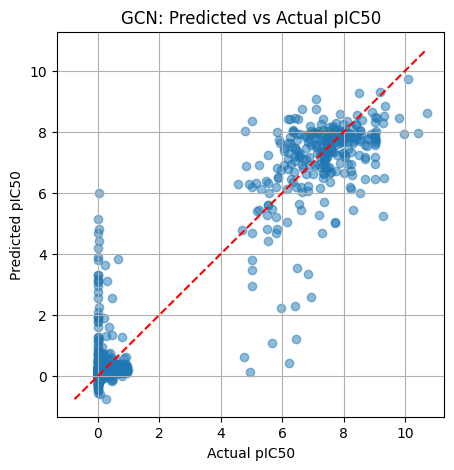

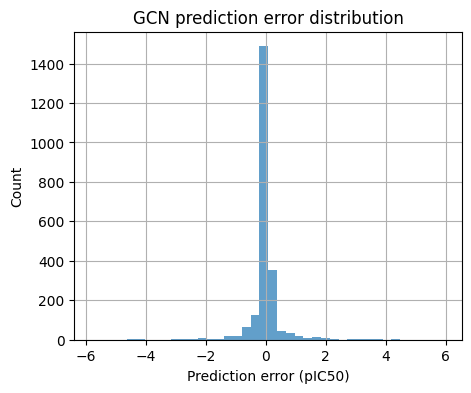

In [ ]:
import matplotlib.pyplot as plt

model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out = model(batch.x, batch.edge_index, batch.batch)
        y = batch.y.view(-1)
        y_true.extend(y.cpu().numpy())
        y_pred.extend(out.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

mae = np.mean(np.abs(y_true - y_pred))
rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
ss_res = np.sum((y_true - y_pred) ** 2)
ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
r2 = 1 - ss_res / ss_tot

print(f"Test MAE: {mae:.3f}")
print(f"Test RMSE: {rmse:.3f}")
print(f"Test R²: {r2:.3f}")

# Scatter plot: predicted vs actual
plt.figure(figsize=(5,5))
plt.scatter(y_true, y_pred, alpha=0.5)
min_v = min(y_true.min(), y_pred.min())
max_v = max(y_true.max(), y_pred.max())
plt.plot([min_v, max_v], [min_v, max_v], 'r--')
plt.xlabel("Actual pIC50")
plt.ylabel("Predicted pIC50")
plt.title("GCN: Predicted vs Actual pIC50")
plt.grid(True)
plt.show()

# Error histogram
errors = y_pred - y_true
plt.figure(figsize=(5,4))
plt.hist(errors, bins=40, alpha=0.7)
plt.xlabel("Prediction error (pIC50)")
plt.ylabel("Count")
plt.title("GCN prediction error distribution")
plt.grid(True)
plt.show()